# Water Dam

 ![Tux, the Linux mascot](figs/dam_fig.png)

# Boundary conditions

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [4]:
numericldata = pd.read_excel('/Users/hervesv/Documents/CloudDrive/Fac/M1/RWTH_ML/Dam Flow/heads/20_5_25.xlsx',header=0)
X = numericldata['X'].to_numpy()
Y = numericldata['Y'].to_numpy()
h = numericldata['FINIT'].to_numpy()

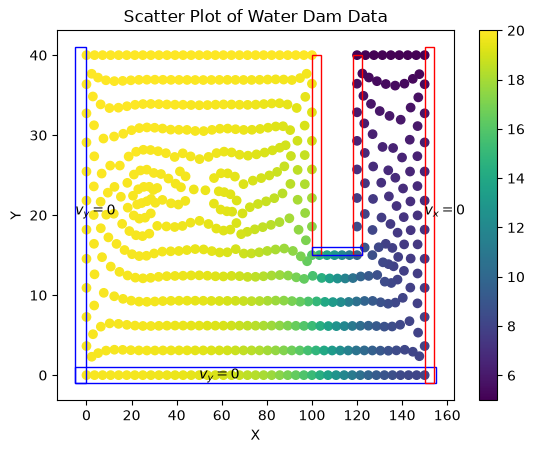

In [5]:
fig, ax = plt.subplots()
    
scatter = ax.scatter(X, Y, c=h, cmap='viridis')
plt.colorbar(scatter)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Scatter Plot of Water Dam Data')

# show boundaries

rect1 = patches.Rectangle(
    (-5, -1),            # Bottom-left corner coordinate
    160,                 # Width along X-axis
    2,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='blue',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect1)
ax.text(50, -0.5, "$v_y = 0$")

rect2 = patches.Rectangle(
    (-5, -1),            # Bottom-left corner coordinate
    5,                 # Width along X-axis
    42,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='blue',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect2)
ax.text(-5, 20, "$v_y = 0$")


rect3 = patches.Rectangle(
    (150, -1),            # Bottom-left corner coordinate
    4,                 # Width along X-axis
    42,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='red',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect3)
ax.text(150, 20, "$v_x = 0$")



rect4 = patches.Rectangle(
    (100, 15),            # Bottom-left corner coordinate
    4,                 # Width along X-axis
    25,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='red',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect4)



rect5 = patches.Rectangle(
    (118, 15),            # Bottom-left corner coordinate
    4,                 # Width along X-axis
    25,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='red',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect5)


rect6 = patches.Rectangle(
    (100, 15),            # Bottom-left corner coordinate
    22,                 # Width along X-axis
    1,                 # Height along Y-axis
    linewidth=1,       # Border thickness
    edgecolor='blue',   # Border color
    facecolor='none'   # Makes it hollow
)

# 3. Add the rectangle to your active axes
ax.add_patch(rect6)



plt.show()

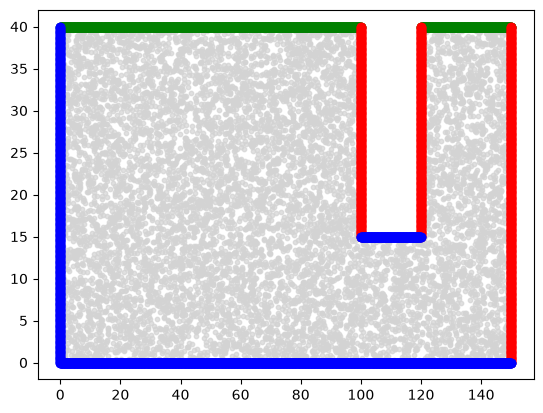

In [16]:
h1 = 20
h2 = 5
hd = 25

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = 150   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - hd    # bottom of dam

num_bc = 100



def sample_boundaries(n_density):
    x1 = np.linspace(x_left, x_dleft, n_density * (x_dleft-x_left))
    y1 = np.ones(n_density * (x_dleft-x_left)) * y_top
    h1 = np.column_stack([x1, y1])

    x2 = np.linspace(x_dright, x_right, n_density*(x_right-x_dright))
    y2 = np.ones(n_density*(x_right-x_dright)) * y_top
    h2 = np.column_stack([x2, y2])


    x3 = np.ones(n_density*(y_top-y_dbot)) * x_dleft
    y3 = np.linspace(y_dbot, y_top, n_density*(y_top-y_dbot))

    x4 = np.ones(n_density*(y_top-y_dbot)) * x_dright
    y4 = np.linspace(y_dbot, y_top, n_density*(y_top-y_dbot))

    x7 = np.ones(n_density*(y_top)) * x_right
    y7 = np.linspace(0, y_top, n_density*(y_top))
    vx0 = np.column_stack([
        np.concatenate([x3, x4, x7]),
        np.concatenate([y3, y4, y7])
    ])

    y5 = np.ones(n_density*(x_dright-x_dleft)) * y_dbot
    x5 = np.linspace(x_dleft, x_dright, n_density*(x_dright-x_dleft))

    y6 = np.zeros(n_density*(x_right))
    x6 = np.linspace(0, x_right, n_density*(x_right))

    x8 = np.ones(n_density*(y_top)) * x_left
    y8 = np.linspace(0, y_top, n_density*(y_top))
    vy0 = np.column_stack([
        np.concatenate([x5, x6, x8]),
        np.concatenate([y5, y6, y8])
    ])

    return {
        "h1": h1,
        "h2": h2,
        "vx0": vx0,
        "vy0": vy0,
    }

def sample_interior_points(num_points=1000):
    sampled_x = []
    sampled_y = []
    
    while len(sampled_x) < num_points:
        # 1. Generate a random candidate point inside the global bounding box
        x_candidate = np.random.uniform(x_left, x_right)
        y_candidate = np.random.uniform(y_bot, y_top)
        
        # 2. Check if the point falls inside the forbidden dam cutout zone
        is_inside_dam = (x_dleft <= x_candidate <= x_dright) and (y_dbot <= y_candidate <= y_top)
        
        # 3. Only keep the point if it is NOT inside the dam
        if not is_inside_dam:
            sampled_x.append(x_candidate)
            sampled_y.append(y_candidate)
            
    return np.array(sampled_x), np.array(sampled_y)


# Generate boundary points
n_density = 10
bc = sample_boundaries(n_density)

# Generate 1,000 interior points
x_internal, y_internal = sample_interior_points(num_points=10000)


y_color = "blue" # vy = 0
x_color = "red"  # vx = 0
val_color = "green"



plt.scatter(x_internal, y_internal, color='lightgray', s=10, label='Interior Sampled Points', alpha=0.7)

plt.scatter(bc['h1'][:, 0], bc['h1'][:, 1], color=val_color)
plt.scatter(bc['h2'][:, 0], bc['h2'][:, 1], color=val_color)
plt.scatter(bc["vx0"][:, 0], bc["vx0"][:, 1], color=x_color)
plt.scatter(bc["vy0"][:, 0], bc["vy0"][:, 1], color=y_color)




plt.show()